In [2]:
import numpy as py
import pandas as pd
import seaborn as sns

In [4]:
df =pd.read_csv("student_performance_dataset.csv")


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        200 non-null    int64  
 1   Gender            200 non-null    object 
 2   Study_Hours       200 non-null    int64  
 3   Attendance        200 non-null    int64  
 4   Sleep_Hours       200 non-null    int64  
 5   Parent_Education  200 non-null    object 
 6   Extracurricular   200 non-null    object 
 7   Previous_Score    200 non-null    int64  
 8   Final_Score       200 non-null    float64
dtypes: float64(1), int64(5), object(3)
memory usage: 14.2+ KB


In [8]:
df2 =df.copy()
df2

,Student_ID,Gender,Study_Hours,Attendance,Sleep_Hours,Parent_Education,Extracurricular,Previous_Score,Final_Score
0,1,Male,2,61,7,PUC,Yes,55,41.0
1,2,Male,10,87,5,PUC,Yes,41,81.6
2,3,Female,10,61,9,PUC,No,52,82.0
3,4,Female,1,70,8,PUC,Yes,61,51.3
4,5,Female,2,65,8,Graduate,No,46,44.3
...,...,...,...,...,...,...,...,...,...
195,196,Male,9,93,8,PUC,No,50,77.2
196,197,Male,8,83,9,Graduate,Yes,46,70.3
197,198,Female,5,88,9,High School,Yes,49,71.2
198,199,Female,6,61,8,Graduate,Yes,43,62.3


In [9]:
df.isnull().sum()

Student_ID          0
Gender              0
Study_Hours         0
Attendance          0
Sleep_Hours         0
Parent_Education    0
Extracurricular     0
Previous_Score      0
Final_Score         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df =df.drop("Student_ID",axis =1)

In [14]:
df =df.drop("Gender",axis =1)

In [15]:
df= df.drop("Parent_Education",axis =1)

In [16]:
df

,Study_Hours,Attendance,Sleep_Hours,Extracurricular,Previous_Score,Final_Score
0,2,61,7,Yes,55,41.0
1,10,87,5,Yes,41,81.6
2,10,61,9,No,52,82.0
3,1,70,8,Yes,61,51.3
4,2,65,8,No,46,44.3
...,...,...,...,...,...,...
195,9,93,8,No,50,77.2
196,8,83,9,Yes,46,70.3
197,5,88,9,Yes,49,71.2
198,6,61,8,Yes,43,62.3


In [19]:
df = pd.get_dummies(df, columns=["Extracurricular"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study_Hours          200 non-null    int64  
 1   Attendance           200 non-null    int64  
 2   Sleep_Hours          200 non-null    int64  
 3   Previous_Score       200 non-null    int64  
 4   Final_Score          200 non-null    float64
 5   Extracurricular_No   200 non-null    bool   
 6   Extracurricular_Yes  200 non-null    bool   
dtypes: bool(2), float64(1), int64(4)
memory usage: 8.3 KB


In [21]:
X =df.drop("Final_Score",axis =1)
y =df["Final_Score"]

<Axes: xlabel='Study_Hours', ylabel='Final_Score'>

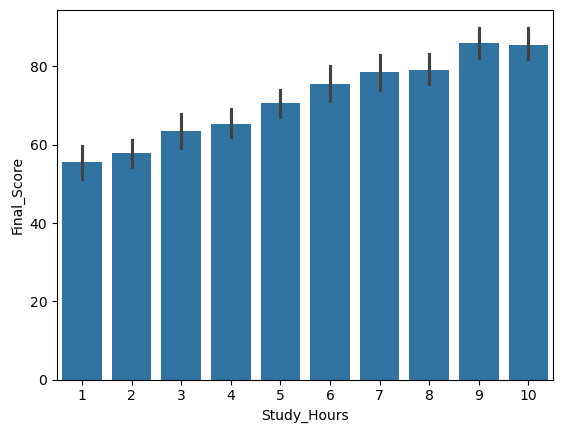

In [39]:

sns.barplot(data =df,
               x =df["Study_Hours"],
               y =df["Final_Score"]
               )


<Axes: xlabel='Study_Hours', ylabel='Final_Score'>

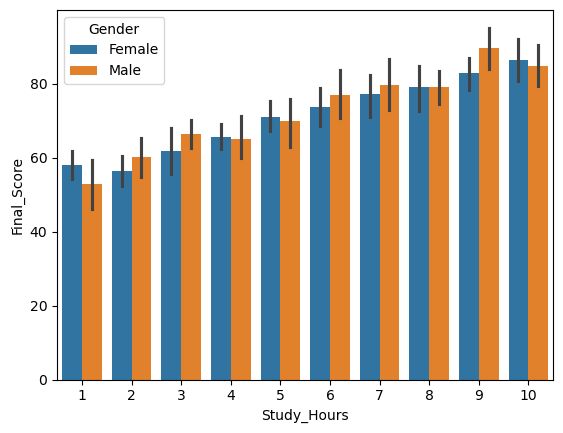

In [35]:
# we can check  a really gender is really matters or like parenting is imp or not
sns.barplot(data =df2,
               x =df["Study_Hours"],
               y =df["Final_Score"],
               hue ="Gender"
               )
#see genger is not mattering here beacuase everyone is at the same level

<Axes: xlabel='Study_Hours', ylabel='Final_Score'>

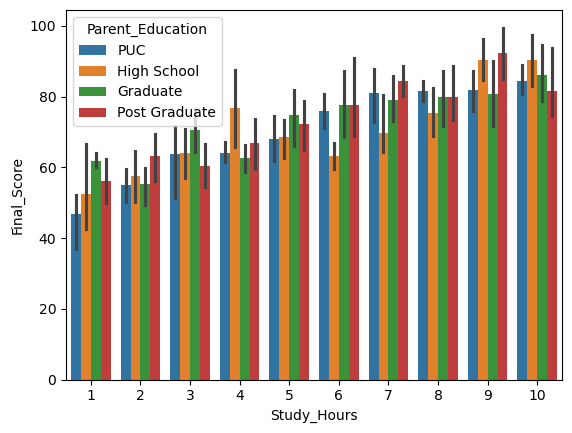

In [37]:
sns.barplot(
    data =df2,
    x=df["Study_Hours"],
    y =df["Final_Score"],
    hue ="Parent_Education"
)
# ya i think that we should add this into our model beacuase almost all the time graduate students are scoring  more marks


In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred = model.predict(X_test)

In [27]:
result = pd.DataFrame({
    "actual":y_test,
    "predicted":y_pred
}   
)
print(result.head(10))

     actual  predicted
95     78.7  79.478539
15     64.0  55.613473
30     66.4  61.468686
158    42.5  46.244053
128    88.7  88.260878
115    87.5  83.218689
69     84.7  87.531022
170    66.0  61.188520
174    86.2  84.439030
45     66.2  70.182399


In [28]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8606785423843322